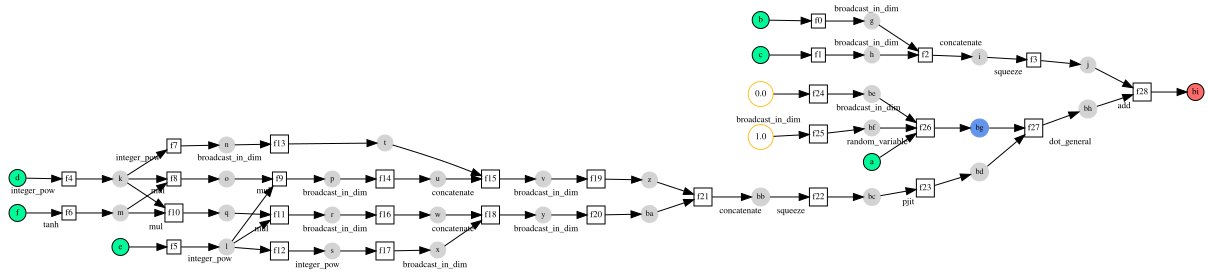

In [9]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom
import math

from jax import core
from jax import lax
from jax import numpy as jnp
from jax._src.util import safe_map

import jax

from probjax.core.custom_primitives.random_variable import rv, rv_p
import matplotlib.pyplot as plt
from probjax.distributions import Normal, Uniform, MultivariateNormal, Independent

from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.core.transformation import trace
from utils import make_flow

sqrt2 = math.sqrt(2)

def simulator_slcp(key, theta0, theta1, theta2, theta3, theta4):
    """Simulator for the two moons problem."""
    #key1, key2, key3, key4 = jrandom.split(key, 4)
    mean = jnp.stack([theta0, theta1]).squeeze()
    s_1 = theta2**2
    s_2 = theta3**2
    rho = jnp.tanh(theta4)
    cov = jnp.array([[s_1**2, rho*s_1*s_2], [rho*s_1*s_2, s_2**2]]).squeeze()
    L = jnp.linalg.cholesky(cov)
    p = Independent(Normal(jnp.zeros(2), jnp.ones(2)), 1)
    x = rv(p, "eps")
    x_obs = mean + L@x(key)

    return x_obs

jaxpr = jax.make_jaxpr(simulator_slcp)(jrandom.PRNGKey(1), jnp.ones(1), jnp.ones(1), jnp.ones(1), jnp.ones(1),jnp.ones(1))

import networkx as nx
g = JaxprGraph(jaxpr.jaxpr)
g

In [4]:
trace_simulator = trace(simulator_slcp)

In [5]:
thetas = jrandom.uniform(jrandom.PRNGKey(1), shape=(100000, 5), minval=-2., maxval=2.)
xs = jnp.stack(jax.vmap(simulator_slcp)(jrandom.split(jrandom.PRNGKey(2), 100000), thetas[:,0], thetas[:, 1], thetas[:, 2], thetas[:, 3], thetas[:, 4]), axis=0)

traces = jax.vmap(trace_simulator)(jrandom.split(jrandom.PRNGKey(2), 100000),  thetas[:,0], thetas[:, 1], thetas[:, 2], thetas[:, 3], thetas[:, 4])

In [8]:
traces["bo"]

Array([[-1.808,  5.796],
       [-1.498,  0.399],
       [ 1.477, -1.126],
       ...,
       [ 2.401, -0.646],
       [ 0.673, -0.264],
       [ 1.539,  0.643]], dtype=float32)

In [4]:
import haiku as hk
from functools import partial

@hk.without_apply_rng
@hk.transform
def sample(key, context):
    flow = make_flow(context,event_shape=(2,), num_layers=5, hidden_sizes=(50,50), num_bins=10)
    return flow.sample(seed=key)

@hk.without_apply_rng
@hk.transform
def log_prob(val, context):
    flow = make_flow(context,event_shape=(2,), num_layers=5, hidden_sizes=(50,50), num_bins=10)
    return flow.log_prob(val)

@partial(jax.vmap, in_axes=(None, 0,0))
@jax.jit
def log_prob_fn(params, x, context):
    return log_prob.apply(params, x, context)

@partial(jax.vmap, in_axes=(None, 0,None))
@jax.jit
def sample_fn(params, key, context):
    return sample.apply(params, key, context)

@jax.jit
def loss_fn(params, x,context):
    return -log_prob_fn(params, x,context).mean()

In [5]:
import optax

params = sample.init(jax.random.PRNGKey(42), jax.random.PRNGKey(0), jnp.ones(2))
x = sample.apply(params, jax.random.PRNGKey(0), jnp.ones(2))

optimizer = optax.adam(1e-2)
initial_opt_state = optimizer.init(params)

@jax.jit
def step(params, opt_state, x, context):
    values, grads = jax.value_and_grad(loss_fn)(params, x,context)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, values

x = jax.random.normal(jax.random.PRNGKey(0), (1000,2))*0.1 + 0.5
opt_state = initial_opt_state

In [6]:
for i in range(1500):
    idx = jax.random.choice(jax.random.PRNGKey(i), xs.shape[0], shape=(4096,), replace=False)
    params, opt_state, values = step(params, opt_state, thetas[idx], xs[idx])
    if (i % 300 )== 0:
        print(values)

2.7725887
-2.6675668
-2.741238
-3.1365795
-2.7292442


In [7]:
theta_o = thetas[0]
x_o = xs[0]

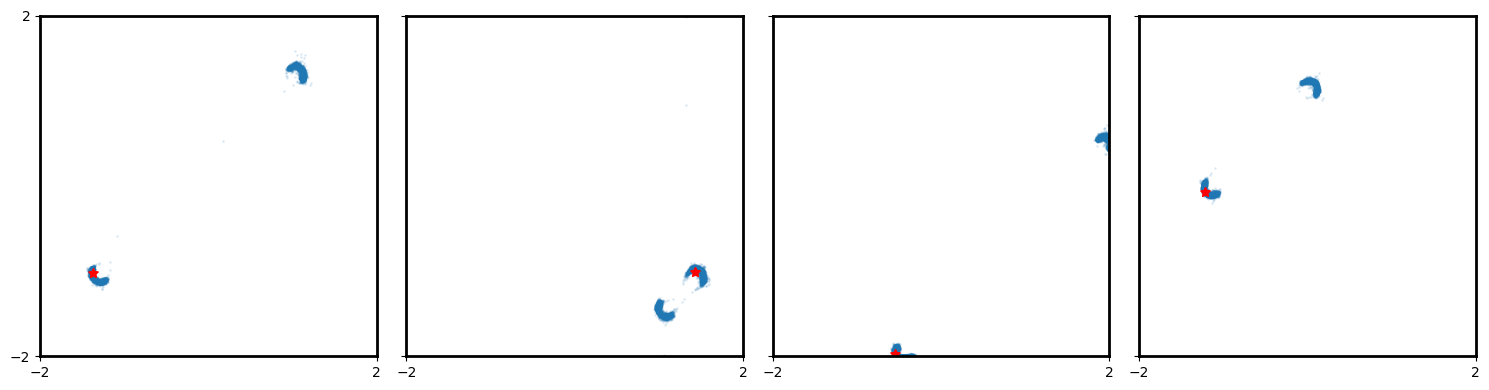

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i in range(4):
    x_o = xs[i]
    theta_o = thetas[i]
    reference = sample_fn(params, jrandom.split(jax.random.PRNGKey(0), 10000), x_o)
    axes[i].scatter(reference[:,0], reference[:,1], alpha=0.1, s=1)
    axes[i].scatter(theta_o[0], theta_o[1], color='red', s= 50, marker=(5,1))
    plt.setp(axes[i].spines.values(), linewidth=2.)
    axes[i].set_xlim(-2,2)
    axes[i].set_ylim(-2,2)
    axes[i].set_yticks([-2, 2])
    axes[i].set_xticks([-2, 2])
    if i > 0:
        #axes[i].set_yticklabels([])
        axes[i].set_yticklabels([])
fig.tight_layout()

# Manually constructing an inverse simulator

In [9]:
# Requires two models
import distrax
from utils import mmd

@hk.without_apply_rng
@hk.transform
def model(x):
    mlp = hk.Sequential([
        hk.Linear(100), jax.nn.relu,
        hk.Linear(100), jax.nn.relu,
        hk.Linear(46),
        hk.Reshape(tuple((1,)) + (46,), preserve_dims=-1),
    ])
    out = mlp(x)
    t = distrax.RationalQuadraticSpline(out, range_min=-0.5, range_max=0.5)
    #transforms = distrax.Chain([distrax.ScalarAffine(x + 0.1, -1.),distrax.Lambda(lambda x: jnp.exp(x)),t])
    transforms = distrax.Chain([t])
    #return distrax.Transformed(distrax.Normal(0, 1.), transforms)
    return distrax.Transformed(distrax.Uniform(-0.5, 0.5), transforms)

params1 = model.init(jax.random.PRNGKey(42), jnp.ones((1,)))
f1 = model.apply


In [10]:
@hk.without_apply_rng
@hk.transform
def model(x):
    mlp = hk.Sequential([
        hk.Linear(100), jax.nn.relu,
        hk.Linear(100), jax.nn.relu,
        hk.Linear(46),
        hk.Reshape(tuple((1,)) + (46,), preserve_dims=-1),
    ])
    out = mlp(x)
    t = distrax.RationalQuadraticSpline(out, range_min=0., range_max=0.2)
    #transforms = distrax.Chain([distrax.ScalarAffine(x + 0.1, -1.),distrax.Lambda(lambda x: jnp.exp(x)),t])
    #return distrax.Transformed(distrax.Normal(0, 1.), transforms)
    return distrax.Transformed(distrax.Normal(0.1, 0.01), t)

params2 = model.init(jax.random.PRNGKey(42), jnp.ones((1,)))
f2 = model.apply


In [11]:
A = jnp.array([[1.,1.], [-1., 1.]])

def inverse_two_moons(key, t,y):
    key1, key2, key3, key4 = jrandom.split(key, 4)
    q_o = f1(params1, jnp.asarray(t))
    o = q_o.sample(seed=key1)
    #o = jrandom.normal(key1, (2,))*0.1
    n = o - 0.25 
    s = t - o 
    r = s * 1.4142135623730951
    q_k = f2(params2, jnp.asarray(n))
    k = q_k.sample(seed=key2).squeeze()
    m = n/k
    m = jnp.clip(n/k, 0.000001, 1.)
    #l = jrandom.uniform(key2, (1,), minval=-0.5 * jnp.pi, maxval=0.5 * jnp.pi).squeeze()
    l = jnp.arccos(m) * jrandom.choice(key3, jnp.asarray([-1., 1.]))
    u = jnp.sin(l)
    v = k * u
    x = y - v 
    w = x * 1.4142135623730951
    q = -r 
    p = jrandom.choice(key4, jnp.asarray([-1., 1.])) * q 
    target = jnp.stack([p, w], 0).squeeze()
    out = jnp.linalg.solve(A, target).T
    out = jnp.clip(out, -2, 2)
    return out.split(2) 

/root/miniconda3/envs/rvtorch/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:329: FutureWarning: The arr.split() method is deprecated. Use jax.numpy.split instead.
  warnings.warn(


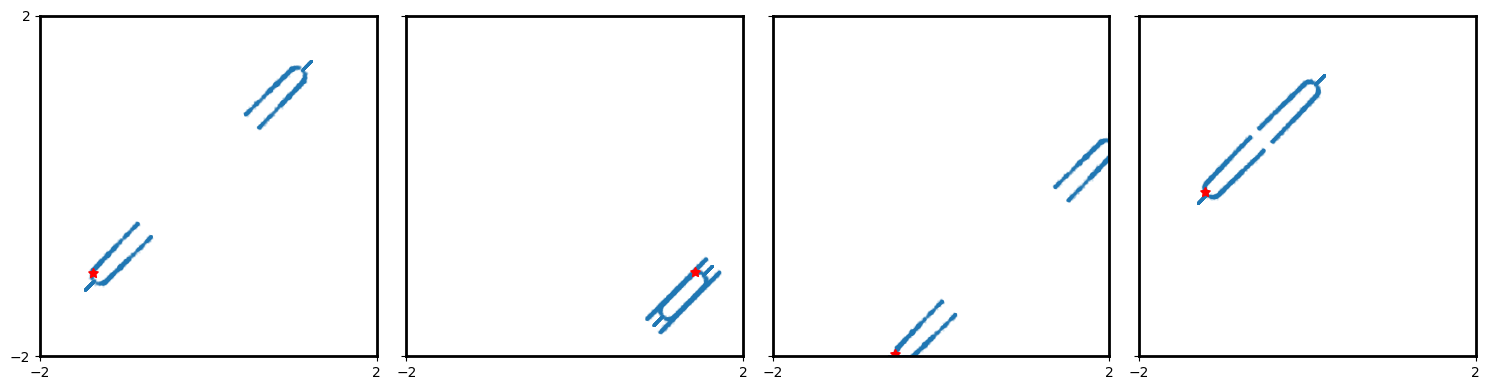

In [12]:

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i in range(4):
    x_o = xs[i]
    theta_o = thetas[i]
    reference = jax.vmap(inverse_two_moons, in_axes=(0, None, None))(jrandom.split(jrandom.PRNGKey(2), 10000), x_o[0].reshape(-1,1), x_o[1].reshape(-1,1))
    axes[i].scatter(reference[0], reference[1], alpha=0.1, s=1)
    axes[i].scatter(theta_o[0], theta_o[1], color='red', s= 50, marker=(5,1))
    plt.setp(axes[i].spines.values(), linewidth=2.)
    axes[i].set_xlim(-2,2)
    axes[i].set_ylim(-2,2)
    axes[i].set_yticks([-2, 2])
    axes[i].set_xticks([-2, 2])
    if i > 0:
        #axes[i].set_yticklabels([])
        axes[i].set_yticklabels([])
fig.tight_layout()

In [13]:
x1 = traces["t"].reshape(-1,1)
o1 =traces["o"].reshape(-1,1)
s1 = traces["s"].reshape(-1,1)

from functools import partial



@partial(jax.vmap, in_axes=(None, 0,0,0,0))
def loss_fn(params, x, latents, s1, rng):
    q = f1(params, x)
    samples = q.sample(seed=rng)
    log_prob = q.log_prob(latents)
    return -jnp.mean(log_prob) + mmd(x - samples, s1, .5)

@jax.jit 
@jax.value_and_grad
def loss_grad(params, x1, o1, s1, rng):
    
    return loss_fn(params, x1, o1, s1, rng).mean()


import optax 

opt = optax.adam(1e-3)
opt_state = opt.init(params1)

for i in range(1500):
    idx = jax.random.choice(jax.random.PRNGKey(i), x1.shape[0], shape=(4096,), replace=False)
    value, gradient = loss_grad(params1, x1[idx], o1[idx], s1[idx], jrandom.split(jax.random.PRNGKey(-1000 + i), idx.shape[0]))
    updates, opt_state = opt.update(gradient,opt_state)
    params1 = optax.apply_updates(params1, updates)
    if (i % 100) == 0:
        print(value)




1.4125506
-1.3717871
-1.7999725
-2.0414855
-2.0819583
-2.0575879
-2.1000795
-2.114
-2.0887299
-2.1317148
-2.1431665
-2.1331968
-2.0883238
-2.0739315
-1.9715579


In [14]:
x1 = traces["n"].reshape(-1,1)
o1 = traces["k"].reshape(-1,1)
m1 = traces["m"].reshape(-1,1)
from functools import partial


@partial(jax.vmap, in_axes=(None, 0,0,0,0))
def loss_fn(params, x, latents, m1, rng):
    q = f2(params, x)
    samples = q.sample(seed=rng)
    log_prob = q.log_prob(latents)
    return -jnp.mean(log_prob) + mmd(x/samples, m1, .5)

@jax.jit 
@jax.value_and_grad
def loss_grad(params, x1, o1, m1, rng):
    
    return loss_fn(params, x1, o1, m1, rng).mean()


import optax 

opt = optax.adam(1e-3)
opt_state = opt.init(params2)

for i in range(1500):
    idx = jax.random.choice(jax.random.PRNGKey(i), x1.shape[0], shape=(4096,), replace=False)
    value, gradient = loss_grad(params2, x1[idx], o1[idx], m1[idx], jrandom.split(jax.random.PRNGKey(-1000 + i), idx.shape[0]))
    updates, opt_state = opt.update(gradient,opt_state)
    params2 = optax.apply_updates(params2, updates)
    if (i % 100) == 0:
        print(value)




-3.0809531
-3.2683067
-3.3598194
-3.4346044
-3.3899035
-3.4019957
-3.3983817
-3.418504
-3.4534724
-3.46666
-3.4522715
-3.416215
-3.4447021
-3.4603403
-3.4588697


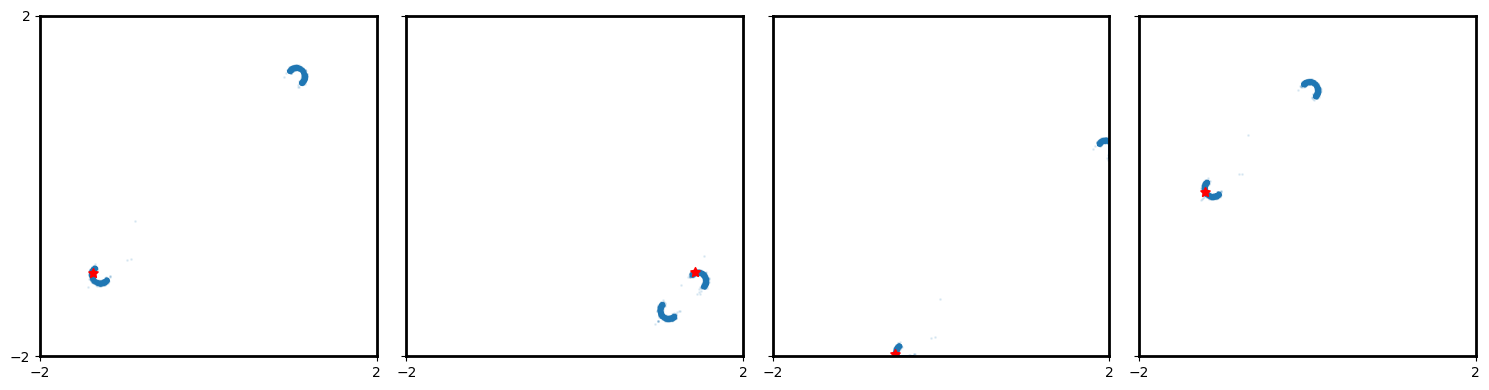

In [15]:

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i in range(4):
    x_o = xs[i]
    theta_o = thetas[i]
    reference = jax.vmap(inverse_two_moons, in_axes=(0, None, None))(jrandom.split(jrandom.PRNGKey(2), 10000), x_o[0].reshape(-1,1), x_o[1].reshape(-1,1))
    axes[i].scatter(reference[0], reference[1], alpha=0.1, s=1)
    axes[i].scatter(theta_o[0], theta_o[1], color='red', s= 50, marker=(5,1))
    plt.setp(axes[i].spines.values(), linewidth=2.)
    axes[i].set_xlim(-2,2)
    axes[i].set_ylim(-2,2)
    axes[i].set_yticks([-2, 2])
    axes[i].set_xticks([-2, 2])
    if i > 0:
        #axes[i].set_yticklabels([])
        axes[i].set_yticklabels([])
fig.tight_layout()